In [122]:
import numpy as np 
import matplotlib.pyplot as plt

import pandas as pd

In [2]:
df=pd.read_csv("Churn_Modelling.csv")

In [3]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3956,3957,15754342,Green,597,Germany,Female,60,0,78539.84,1,0,1,48502.88,0
6254,6255,15721047,Ansell,578,Germany,Male,37,1,135650.88,1,1,0,199428.19,0
1301,1302,15800856,Ewen,643,Spain,Male,34,3,83132.09,1,1,1,21360.88,0
2851,2852,15776454,Hamilton,603,France,Female,48,5,0.00,1,1,0,100478.60,1
3387,3388,15798024,Lori,537,Germany,Male,84,8,92242.34,1,1,1,186235.98,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [12]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [14]:
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)
dummy_cols = [col for col in df.columns if col.startswith("Geography_") or col.startswith("Gender_")]
df[dummy_cols] = df[dummy_cols].astype(int)


In [17]:
df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
7138,430,66,6,135392.31,2,1,1,172852.06,1,1,0,0
5759,679,37,8,77373.87,2,0,1,174873.09,0,1,0,0
7925,586,33,7,0.00,2,1,1,168261.40,0,0,1,0
2245,625,58,10,53772.73,1,1,1,192072.10,1,0,0,0
5819,546,29,5,0.00,1,1,1,94823.95,0,0,0,1


In [18]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["Exited"]),df["Exited"],test_size=0.2,random_state=42)


In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler=StandardScaler()

In [26]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [27]:
x_test_scaled

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(2000, 11))

In [114]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data  import dataset,dataloader 

class ChurnMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(11, 11), 
            nn.ReLU(),
            nn.Linear(11, 3),
            nn.Sigmoid(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model=ChurnMLP()


In [115]:
from torchsummary import summary
model = ChurnMLP()
summary(model, input_size=(11,),batch_size=2)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [2, 11]             132
              ReLU-2                    [2, 11]               0
            Linear-3                     [2, 3]              36
           Sigmoid-4                     [2, 3]               0
            Linear-5                     [2, 1]               4
           Sigmoid-6                     [2, 1]               0
Total params: 172
Trainable params: 172
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [116]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [117]:
# Inputs
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_tensor  = torch.tensor(x_test_scaled, dtype=torch.float32)

# Labels (binary classification, so shape = (N,1))
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [123]:
epochs = 100
losses=[]
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(x_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Compute accuracy (manual)
    with torch.no_grad():
        preds = (outputs > 0.5).float()
        acc = (preds == y_train_tensor).float().mean()
    
    losses.append(loss.item())
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")


Epoch 1/100 | Loss: 0.5975 | Acc: 0.7945
Epoch 2/100 | Loss: 0.5967 | Acc: 0.7945
Epoch 3/100 | Loss: 0.5958 | Acc: 0.7945
Epoch 4/100 | Loss: 0.5950 | Acc: 0.7945
Epoch 5/100 | Loss: 0.5942 | Acc: 0.7945
Epoch 6/100 | Loss: 0.5934 | Acc: 0.7945
Epoch 7/100 | Loss: 0.5925 | Acc: 0.7945
Epoch 8/100 | Loss: 0.5917 | Acc: 0.7945
Epoch 9/100 | Loss: 0.5909 | Acc: 0.7945
Epoch 10/100 | Loss: 0.5901 | Acc: 0.7945
Epoch 11/100 | Loss: 0.5893 | Acc: 0.7945
Epoch 12/100 | Loss: 0.5885 | Acc: 0.7945
Epoch 13/100 | Loss: 0.5877 | Acc: 0.7945
Epoch 14/100 | Loss: 0.5869 | Acc: 0.7945
Epoch 15/100 | Loss: 0.5862 | Acc: 0.7945
Epoch 16/100 | Loss: 0.5854 | Acc: 0.7945
Epoch 17/100 | Loss: 0.5846 | Acc: 0.7945
Epoch 18/100 | Loss: 0.5838 | Acc: 0.7945
Epoch 19/100 | Loss: 0.5831 | Acc: 0.7945
Epoch 20/100 | Loss: 0.5823 | Acc: 0.7945
Epoch 21/100 | Loss: 0.5816 | Acc: 0.7945
Epoch 22/100 | Loss: 0.5808 | Acc: 0.7945
Epoch 23/100 | Loss: 0.5801 | Acc: 0.7945
Epoch 24/100 | Loss: 0.5793 | Acc: 0.7945
E

In [120]:
model.eval()
with torch.no_grad():
    test_outputs = model(x_test_tensor)
    test_preds = (test_outputs > 0.5).float()
    test_acc = (test_preds == y_test_tensor).float().mean()

print("Test Accuracy:", test_acc.item())


Test Accuracy: 0.8034999966621399


In [121]:
for param in model.parameters():
    print(param)


Parameter containing:
tensor([[ 0.2899, -0.0333,  0.2739, -0.3658, -0.1029,  0.1181,  0.3607,  0.3372,
         -0.3810,  0.1908,  0.0555],
        [ 0.1552, -0.1107,  0.3161, -0.1333,  0.0991,  0.1587,  0.3074, -0.3691,
          0.0374, -0.1816,  0.2806],
        [-0.3313, -0.2657,  0.1113, -0.1640,  0.1733,  0.2637, -0.3636, -0.3660,
         -0.2867, -0.2661, -0.3294],
        [ 0.2725,  0.0712, -0.3784, -0.2616, -0.1783,  0.3902, -0.0416,  0.3491,
         -0.3622, -0.2347,  0.0185],
        [-0.3648,  0.1411, -0.1682, -0.2518,  0.2349,  0.2235,  0.0543,  0.1504,
          0.0152, -0.3744,  0.2870],
        [ 0.2519, -0.0968,  0.3084, -0.1642,  0.1741, -0.2966, -0.2757,  0.1619,
         -0.0640,  0.1967, -0.3015],
        [-0.0567,  0.0458, -0.0303, -0.0114,  0.2175, -0.0576,  0.0887,  0.0716,
          0.1081, -0.1628, -0.1955],
        [-0.1832, -0.1651,  0.2498, -0.0382,  0.2175,  0.2013,  0.2384, -0.2963,
         -0.1488,  0.1113,  0.1207],
        [ 0.0789, -0.3086, -0.2648

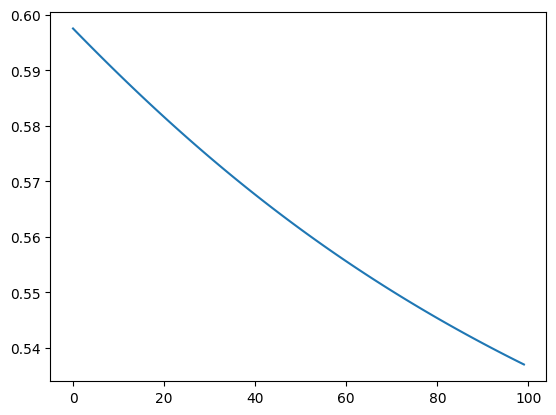

In [126]:
plt.plot(losses)

